In [1]:
# Importing necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

In [2]:
dataset_path = r"D:\archive (9)\animals\animals"  
classes = os.listdir(dataset_path)
num_classes = len(classes)

# Display the number of classes along with names
print(f'Number of Classes: {num_classes}')
print(f'Classes: {classes}')

Number of Classes: 90
Classes: ['antelope', 'badger', 'bat', 'bear', 'bee', 'beetle', 'bison', 'boar', 'butterfly', 'cat', 'caterpillar', 'chimpanzee', 'cockroach', 'cow', 'coyote', 'crab', 'crow', 'deer', 'dog', 'dolphin', 'donkey', 'dragonfly', 'duck', 'eagle', 'elephant', 'flamingo', 'fly', 'fox', 'goat', 'goldfish', 'goose', 'gorilla', 'grasshopper', 'hamster', 'hare', 'hedgehog', 'hippopotamus', 'hornbill', 'horse', 'hummingbird', 'hyena', 'jellyfish', 'kangaroo', 'koala', 'ladybugs', 'leopard', 'lion', 'lizard', 'lobster', 'mosquito', 'moth', 'mouse', 'octopus', 'okapi', 'orangutan', 'otter', 'owl', 'ox', 'oyster', 'panda', 'parrot', 'pelecaniformes', 'penguin', 'pig', 'pigeon', 'porcupine', 'possum', 'raccoon', 'rat', 'reindeer', 'rhinoceros', 'sandpiper', 'seahorse', 'seal', 'shark', 'sheep', 'snake', 'sparrow', 'squid', 'squirrel', 'starfish', 'swan', 'tiger', 'turkey', 'turtle', 'whale', 'wolf', 'wombat', 'woodpecker', 'zebra']


In [3]:
dataset_path = r"D:\archive (9)\animals\animals"
classes = os.listdir(dataset_path)
num_classes = len(classes)
print(f"Total Classes: {num_classes}\n")

# Print number of images per class
class_counts = {}
for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    img_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_counts[class_name] = len(img_files)
    print(f"{class_name}: {len(img_files)} images")

Total Classes: 90

antelope: 60 images
badger: 60 images
bat: 60 images
bear: 60 images
bee: 60 images
beetle: 60 images
bison: 60 images
boar: 60 images
butterfly: 60 images
cat: 60 images
caterpillar: 60 images
chimpanzee: 60 images
cockroach: 60 images
cow: 60 images
coyote: 60 images
crab: 60 images
crow: 60 images
deer: 60 images
dog: 60 images
dolphin: 60 images
donkey: 60 images
dragonfly: 60 images
duck: 60 images
eagle: 60 images
elephant: 60 images
flamingo: 60 images
fly: 60 images
fox: 60 images
goat: 60 images
goldfish: 60 images
goose: 60 images
gorilla: 60 images
grasshopper: 60 images
hamster: 60 images
hare: 60 images
hedgehog: 60 images
hippopotamus: 60 images
hornbill: 60 images
horse: 60 images
hummingbird: 60 images
hyena: 60 images
jellyfish: 60 images
kangaroo: 60 images
koala: 60 images
ladybugs: 60 images
leopard: 60 images
lion: 60 images
lizard: 60 images
lobster: 60 images
mosquito: 60 images
moth: 60 images
mouse: 60 images
octopus: 60 images
okapi: 60 imag

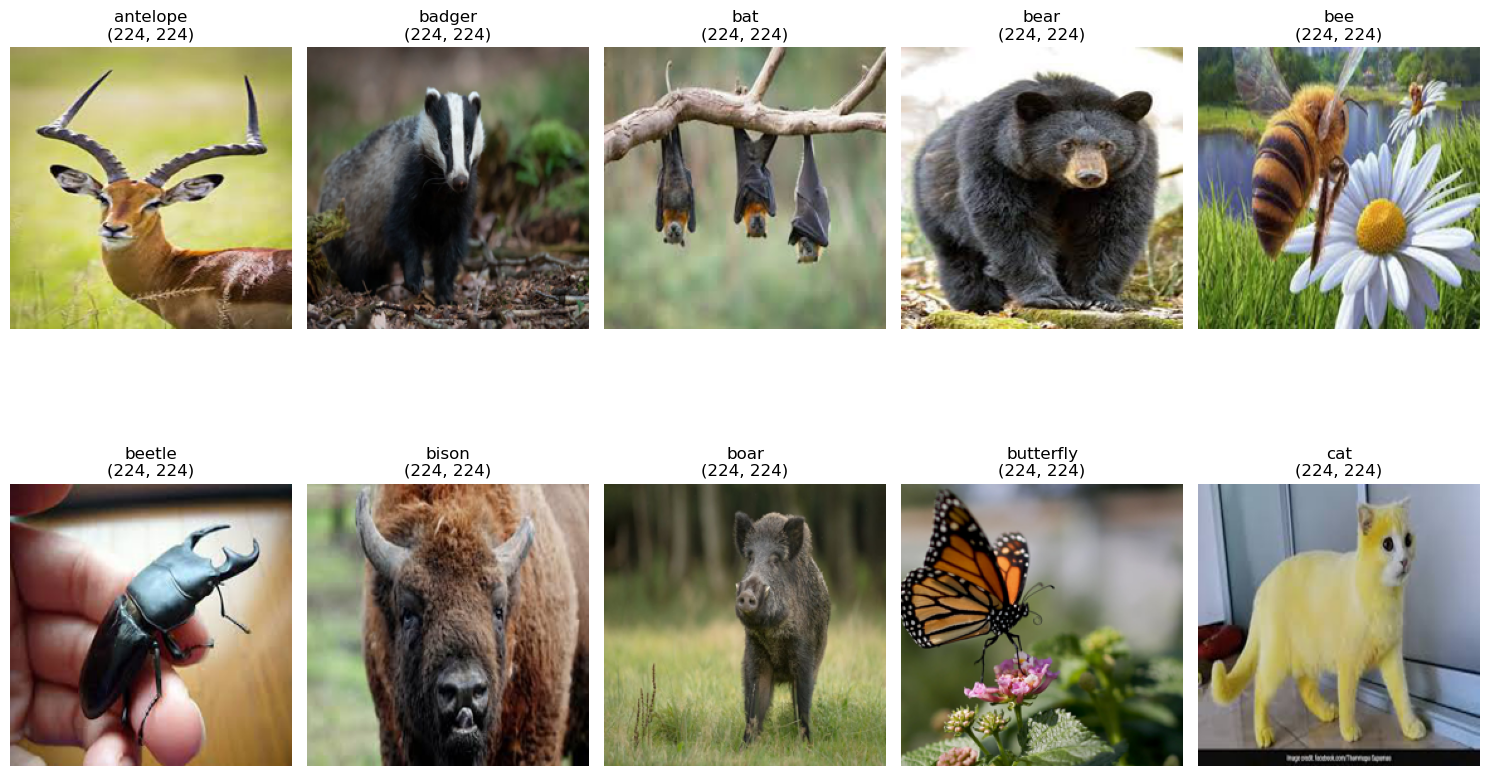

In [4]:
# Show random image from first 10 classes
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(15, 10))

for i, class_name in enumerate(classes[:10]):
    class_path = os.path.join(dataset_path, class_name)
    img_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if img_files:
        img_name = random.choice(img_files)
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path).resize((224, 224))

        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(f"{class_name}\n{img.size}")
        plt.axis('off')

plt.tight_layout()
plt.show()


In [5]:
# Set parameters
img_size = (224, 224)
batch_size = 64
seed = 42  # Ensures reproducibility

# Data augmentation & normalization
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1
)

# Create training generator
train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    seed=seed,
    shuffle=True
)

# Create validation generator
validation_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    seed=seed,
    shuffle=True
)



Found 4860 images belonging to 90 classes.
Found 540 images belonging to 90 classes.


In [6]:
# Map classes
class_indices = train_generator.class_indices
class_names = sorted(list(class_indices.keys()))

# Print class mapping and dataset stats
print("\nClass Mapping:")
for class_name, idx in class_indices.items():
    print(f'{idx:2d}: {class_name}')

print("\nTotal Classes:", len(class_names))
print("Training samples:", train_generator.samples)
print("Validation samples:", validation_generator.samples)



Class Mapping:
 0: antelope
 1: badger
 2: bat
 3: bear
 4: bee
 5: beetle
 6: bison
 7: boar
 8: butterfly
 9: cat
10: caterpillar
11: chimpanzee
12: cockroach
13: cow
14: coyote
15: crab
16: crow
17: deer
18: dog
19: dolphin
20: donkey
21: dragonfly
22: duck
23: eagle
24: elephant
25: flamingo
26: fly
27: fox
28: goat
29: goldfish
30: goose
31: gorilla
32: grasshopper
33: hamster
34: hare
35: hedgehog
36: hippopotamus
37: hornbill
38: horse
39: hummingbird
40: hyena
41: jellyfish
42: kangaroo
43: koala
44: ladybugs
45: leopard
46: lion
47: lizard
48: lobster
49: mosquito
50: moth
51: mouse
52: octopus
53: okapi
54: orangutan
55: otter
56: owl
57: ox
58: oyster
59: panda
60: parrot
61: pelecaniformes
62: penguin
63: pig
64: pigeon
65: porcupine
66: possum
67: raccoon
68: rat
69: reindeer
70: rhinoceros
71: sandpiper
72: seahorse
73: seal
74: shark
75: sheep
76: snake
77: sparrow
78: squid
79: squirrel
80: starfish
81: swan
82: tiger
83: turkey
84: turtle
85: whale
86: wolf
87: wombat

In [7]:
# Load MobileNetV2 as the base model
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the base model weights, training
base_model.trainable = False

# Add custom layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation='softmax')(x) # output layer

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),
              loss = 'categorical_crossentropy',
              metrics = ['accuracy'])
# Model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 3,661,978 (13.97 MB)

 Trainable params: 1,403,994 (5.36 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size,
    epochs=20
)

C:\Users\Dell\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 354s 4s/step - accuracy: 0.0493 - loss: 4.5060 - val_accuracy: 0.5059 - val_loss: 3.2831
Epoch 2/20
 1/75 ━━━━━━━━━━━━━━━━━━━━ 2:29 2s/step - accuracy: 0.3594 - loss: 3.2837

C:\Users\Dell\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


75/75 ━━━━━━━━━━━━━━━━━━━━ 32s 404ms/step - accuracy: 0.3594 - loss: 3.2837 - val_accuracy: 0.5156 - val_loss: 3.2449
Epoch 3/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 321s 4s/step - accuracy: 0.4043 - loss: 3.0122 - val_accuracy: 0.7012 - val_loss: 1.9131
Epoch 4/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 30s 384ms/step - accuracy: 0.5000 - loss: 2.4439 - val_accuracy: 0.7012 - val_loss: 1.8989
Epoch 5/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 318s 4s/step - accuracy: 0.6382 - loss: 1.7774 - val_accuracy: 0.7832 - val_loss: 1.2302
Epoch 6/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 30s 386ms/step - accuracy: 0.7500 - loss: 1.3581 - val_accuracy: 0.7871 - val_loss: 1.2194
Epoch 7/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 302s 4s/step - accuracy: 0.7321 - loss: 1.1906 - val_accuracy: 0.8027 - val_loss: 0.9513
Epoch 8/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 31s 391ms/step - accuracy: 0.6562 - loss: 1.0534 - val_accuracy: 0.7969 - val_loss: 0.9623
Epoch 9/20
75/75 ━━━━━━━━━━━━━━━━━━━━ 315s 4s/step - accuracy: 0.7980 - loss: 0.8976 - val_accuracy: 0.8145 - val_

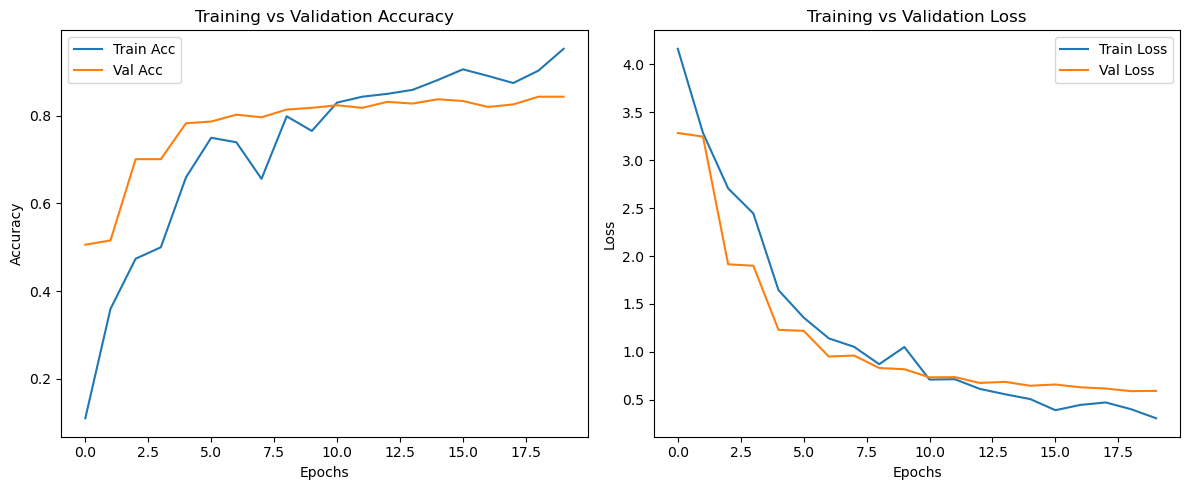

In [9]:
# Plot accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend()

plt.tight_layout()
plt.show()

In [10]:
# Evaluate model
val_loss, val_acc = model.evaluate(validation_generator)
print(f"\n Validation Accuracy: {val_acc:.4f}")
print(f"Validation Loss: {val_loss:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.8368 - loss: 0.6534

 Validation Accuracy: 0.8426
Validation Loss: 0.6017


In [11]:
# Save the trained model
model.save('MCAR.keras')
print("Model saved as 'MCAR.keras'")

Model saved as 'MCAR.keras'


In [16]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

# Prediction function
def predict_animal(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]

    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')
    plt.show()

In [17]:
os.listdir('D:/archive (9)/animals/animals/woodpecker')

['00cb69b40b.jpg',
 '04f92cc314.jpg',
 '059d5994c8.jpg',
 '09cf8f2ad4.jpg',
 '0aa8b4354e.jpg',
 '0ab504123b.jpg',
 '0b30ac6caa.jpg',
 '0befc79b3c.jpg',
 '1ab4288637.jpg',
 '1d360861dd.jpg',
 '1dc55cc123.jpg',
 '1f6a66ff87.jpg',
 '22bf875c82.jpg',
 '24eb6eed1e.jpg',
 '27a3c78bc6.jpg',
 '2a77fae918.jpg',
 '2cd16a0d7c.jpg',
 '2d8702ac8f.jpg',
 '2dd08455b8.jpg',
 '2f5766ad0d.jpg',
 '2f9a1fc195.jpg',
 '35ce530ff7.jpg',
 '3a7fd9e840.jpg',
 '3e427a9c70.jpg',
 '3e9456b779.jpg',
 '3f75058539.jpg',
 '40bf39a0a9.jpg',
 '41bfce3808.jpg',
 '46ad98ef1b.jpg',
 '4fccce1426.jpg',
 '51f520b707.jpg',
 '52a8e86f2c.jpg',
 '53adfd3576.jpg',
 '57f81c8cbb.jpg',
 '58ae524129.jpg',
 '5a1304f5a7.jpg',
 '5a2cf23a16.jpg',
 '5a38442caf.jpg',
 '5d63b8fbe7.jpg',
 '5ec833f7bf.jpg',
 '5f0fd84efc.jpg',
 '63acf22913.jpg',
 '64f23e50cb.jpg',
 '6a92c7f43d.jpg',
 '6e320ac2c1.jpg',
 '71e2aec38d.jpg',
 '72b89ad865.jpg',
 '74d7ef8b1e.jpg',
 '7a56d09260.jpg',
 '7c7fff84ca.jpg',
 '7ccde0b69f.jpg',
 '7d771b2f33.jpg',
 '7fdd65fca4

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


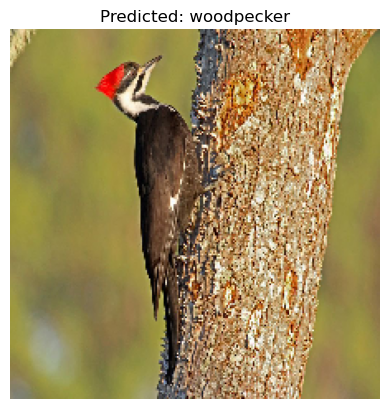

In [19]:
# Example usage (update path as your choice and your needed)
predict_animal('D:/archive (9)/animals/animals/woodpecker/9e74328e36.jpg')